# ParkSight AI — XGBoost Congestion Prediction Model

**Goal:** Predict `congestion_score` (0–100) for any parking violation.

**Real CSV columns (confirmed):**
```
id, latitude, longitude, location, vehicle_number, vehicle_type, description,
violation_type, offence_code, created_datetime, closed_datetime, modified_datetime,
device_id, created_by_id, center_code, police_station, data_sent_to_scita,
junction_name, action_taken_timestamp, data_sent_to_scita_timestamp,
updated_vehicle_number, updated_vehicle_type, validation_status, validation_timestamp
```

**Pipeline:** `CSV → Clean → Features → Labels → XGBoost → Evaluate → Save`

## Step 1: Load CSV

In [2]:
import pandas as pd
import numpy as np
import json, ast, math, os, warnings
warnings.filterwarnings('ignore')

CSV_PATH = 'jan to may police violation_anonymized791b166.csv'

df = pd.read_csv(CSV_PATH, encoding='utf-8', on_bad_lines='skip', low_memory=False)

print(f'Rows: {len(df):,}  |  Columns: {df.shape[1]}')
print(df.columns.tolist())
df.head(3)

Rows: 298,450  |  Columns: 24
['id', 'latitude', 'longitude', 'location', 'vehicle_number', 'vehicle_type', 'description', 'violation_type', 'offence_code', 'created_datetime', 'closed_datetime', 'modified_datetime', 'device_id', 'created_by_id', 'center_code', 'police_station', 'data_sent_to_scita', 'junction_name', 'action_taken_timestamp', 'data_sent_to_scita_timestamp', 'updated_vehicle_number', 'updated_vehicle_type', 'validation_status', 'validation_timestamp']


,id,latitude,longitude,location,vehicle_number,vehicle_type,description,violation_type,offence_code,created_datetime,...,center_code,police_station,data_sent_to_scita,junction_name,action_taken_timestamp,data_sent_to_scita_timestamp,updated_vehicle_number,updated_vehicle_type,validation_status,validation_timestamp
0,FKID000000,12.925557,77.618665,"18th Main Road, Block 2, Koramangala, Bengalur...",FKN00GL0000,CAR,NaN,"[""WRONG PARKING"",""PARKING NEAR ROAD CROSSING""]","[112,104]",2023-11-20 00:28:46+00,...,9.0,Madiwala,True,No Junction,NaN,NaN,FKN00GL0000,MAXI-CAB,approved,2023-11-30 03:08:24.818+00
1,FKID000001,12.905463,77.700778,"Sarjapura Main Road, The Grove, Janatha Colony...",FKN00GL0001,CAR,NaN,"[""NO PARKING""]",[113],2023-11-24 22:46:46+00,...,82.0,Bellandur,False,No Junction,NaN,NaN,NaN,NaN,NaN,NaN
2,FKID000002,12.925449,77.618504,"Koramangala 2nd Block, Kormangala West, Bengal...",FKN00GL0002,CAR,NaN,"[""WRONG PARKING"",""PARKING IN A MAIN ROAD""]","[112,107]",2023-11-20 00:27:46+00,...,9.0,Madiwala,True,No Junction,NaN,NaN,FKN00GL0002,MAXI-CAB,approved,2023-11-30 03:08:56.998+00


## Step 2: Parse Timestamps → Resolution Lag

In [3]:
# created_datetime = when the challan was raised
# closed_datetime  = when it was resolved/closed
# Resolution lag = how long the violation stayed open (key congestion signal)

df['ts_created']  = pd.to_datetime(df['created_datetime'], errors='coerce', utc=True)
df['ts_closed']   = pd.to_datetime(df['closed_datetime'],  errors='coerce', utc=True)

df['resolution_lag_mins'] = (
    (df['ts_closed'] - df['ts_created']).dt.total_seconds() / 60
).clip(lower=0, upper=10080)  # cap at 1 week (10080 min)

# For unresolved (NaN closed_datetime): assume 60-minute default (same as scoring.py)
df['resolution_lag_mins'] = df['resolution_lag_mins'].fillna(60.0)

print(df['resolution_lag_mins'].describe())
print(f"\nUnresolved violations: {df['closed_datetime'].isna().sum():,}")

count    298450.0
mean         60.0
std           0.0
min          60.0
25%          60.0
50%          60.0
75%          60.0
max          60.0
Name: resolution_lag_mins, dtype: float64

Unresolved violations: 298,450


## Step 3: Parse violation_type → Severity Weight

`violation_type` is a JSON array: `["WRONG PARKING", "PARKING NEAR ROAD CROSSING"]`

In [4]:
# Severity weights from scoring.py
SEVERITY_MAP = {
    "DOUBLE PARKING": 5.0,
    "PARKING NEAR BUSTOP/SCHOOL/HOSPITAL ETC": 4.0,
    "PARKING IN A MAIN ROAD": 4.0,
    "PARKING ON FOOTPATH": 3.0,
    "PARKING NEAR ROAD CROSSING": 3.0,
    "WRONG PARKING": 2.0,
    "NO PARKING": 2.0,
    "PARKING OPPOSITE TO ANOTHER PARKED VEHICLE": 3.0,
}
DEFAULT_SEV = 1.5

def parse_vtype(raw):
    if pd.isna(raw) or str(raw).strip() in ('NULL', 'null', ''):
        return []
    try:
        return json.loads(str(raw).replace("'", '"'))
    except:
        try:
            return ast.literal_eval(str(raw))
        except:
            return [str(raw)]

def max_severity(raw):
    types = parse_vtype(raw)
    if not types:
        return DEFAULT_SEV
    return max(SEVERITY_MAP.get(t.upper().strip(), DEFAULT_SEV) for t in types)

def num_vtypes(raw):
    return len(parse_vtype(raw))

def primary_vtype(raw):
    types = parse_vtype(raw)
    return types[0].upper().strip() if types else 'UNKNOWN'

df['severity_weight']    = df['violation_type'].apply(max_severity)
df['num_violation_types']= df['violation_type'].apply(num_vtypes)
df['primary_violation']  = df['violation_type'].apply(primary_vtype)

print(df['primary_violation'].value_counts().head(10))
print('\nSeverity weight distribution:')
print(df['severity_weight'].value_counts())

primary_violation
WRONG PARKING                                147493
NO PARKING                                   128624
PARKING IN A MAIN ROAD                        17084
PARKING ON FOOTPATH                            2447
DEFECTIVE NUMBER PLATE                          807
PARKING NEAR ROAD CROSSING                      646
PARKING NEAR BUSTOP/SCHOOL/HOSPITAL ETC         594
DOUBLE PARKING                                  316
PARKING OTHER THAN BUS STOP                     194
PARKING NEAR TRAFFIC LIGHT OR ZEBRA CROSS       125
Name: count, dtype: int64

Severity weight distribution:
severity_weight
2.0    267812
4.0     24405
3.0      4196
5.0      2037
Name: count, dtype: int64


## Step 4: Time Features

In [5]:
df['hour_of_day']  = df['ts_created'].dt.hour.fillna(12).astype(int)
df['day_of_week']  = df['ts_created'].dt.dayofweek.fillna(0).astype(int)  
df['month']        = df['ts_created'].dt.month.fillna(1).astype(int)        
df['is_weekend']   = (df['day_of_week'] >= 5).astype(int)                   
df['is_peak_hour'] = df['hour_of_day'].apply(lambda h: 1 if (8<=h<=10 or 17<=h<=20) else 0)

print(df['hour_of_day'].value_counts().sort_index())

hour_of_day
0     21760
1     17155
2     24770
3     25707
4     29102
5     34085
6     26890
7     14608
8      8556
9      3145
10      518
11      577
12      224
13       56
14       16
15       66
16      416
17      818
18     1971
19    10713
20    11834
21    19763
22    22839
23    22861
Name: count, dtype: int64


## Step 5: GPS Features + Junction Flag

In [6]:
# Parse GPS: columns are 'latitude' and 'longitude'
df['lat'] = pd.to_numeric(df['latitude'],  errors='coerce')
df['lon'] = pd.to_numeric(df['longitude'], errors='coerce')

# Drop rows with missing GPS (can't compute density or heatmap without it)
before = len(df)
df = df.dropna(subset=['lat', 'lon'])
print(f'Dropped {before - len(df):,} rows with missing GPS | Remaining: {len(df):,}')

# junction_name = 'No Junction' means not at junction
# Any other value = at a junction → higher congestion weight
df['is_junction'] = (~df['junction_name'].isin(['No Junction', 'NULL', 'null', ''])
                     & df['junction_name'].notna()).astype(int)

print(f"\nAt junction: {df['is_junction'].sum():,} | Not at junction: {(df['is_junction']==0).sum():,}")
print(df['junction_name'].value_counts().head(10))

Dropped 0 rows with missing GPS | Remaining: 298,450

At junction: 150,565 | Not at junction: 147,885
junction_name
No Junction                         147880
BTP051 - Safina Plaza Junction       15449
BTP082 - KR Market Junction          11538
BTP040 - Elite Junction              10718
BTP044 - Sagar Theatre Junction      10549
BTP211 - Central Street Junction      5388
BTP058 - Subbanna Junction            5189
BTP027 - Modi Bridge Junction         4584
BTP020 - Hosahalli Metro Station      4101
BTP057 - Anand Rao Junction           3935
Name: count, dtype: int64


## Step 6: Vehicle Type → Impact Multiplier

In [7]:
# Use updated_vehicle_type if available (more accurate), else vehicle_type
df['vehicle_type_clean'] = df['updated_vehicle_type'].fillna(df['vehicle_type'])
df['vehicle_type_clean'] = df['vehicle_type_clean'].fillna('UNKNOWN').astype(str).str.upper().str.strip()

VEHICLE_IMPACT = {
    'LGV': 1.5, 'TANKER': 1.5, 'PRIVATE BUS': 1.5, 'BUS': 1.3,
    'TRUCK': 1.4, 'AUTO RICKSHAW': 1.1, 'MAXI-CAB': 1.2, 'TEMPO': 1.3,
    'SCOOTER': 1.0, 'MOTORCYCLE': 1.0, 'CAR': 1.0, 'JEEP': 1.0,
}

df['vehicle_impact'] = df['vehicle_type_clean'].map(VEHICLE_IMPACT).fillna(1.0)

print(df['vehicle_type_clean'].value_counts().head(10))

vehicle_type_clean
SCOOTER           95440
CAR               87638
MOTOR CYCLE       41269
PASSENGER AUTO    37568
MAXI-CAB          11836
LGV                8290
GOODS AUTO         2974
MOPED              2111
PRIVATE BUS        1656
VAN                1524
Name: count, dtype: int64


## Step 7: Validation / SCITA Status

In [8]:
# validation_status: 'approved' / 'rejected' / NaN (pending)
df['is_approved'] = (df['validation_status'].astype(str).str.lower() == 'approved').astype(int)

# data_sent_to_scita: TRUE/FALSE — whether enforcement was escalated
df['sent_to_scita'] = df['data_sent_to_scita'].map(
    {'TRUE': 1, 'True': 1, True: 1, 'FALSE': 0, 'False': 0, False: 0}
).fillna(0).astype(int)

print(df[['is_approved','sent_to_scita']].value_counts())

is_approved  sent_to_scita
0            1                140496
1            1                115397
0            0                 42554
1            0                     3
Name: count, dtype: int64


## Step 8: Spatial Density Feature (KNN via BallTree)

**KNN role:** For each violation, count how many other violations exist within 500m radius.  
This becomes the `density_500m` feature — the single biggest driver of congestion.  
KNN is used as a **feature generator**, not as the classifier itself.

In [9]:
from sklearn.neighbors import BallTree

coords_rad = np.radians(df[['lat', 'lon']].values)
RADIUS_500M = 500 / 6371000  # 500 metres in radians

print(f'Building BallTree on {len(df):,} points...')
tree = BallTree(coords_rad, metric='haversine')

counts = tree.query_radius(coords_rad, r=RADIUS_500M, count_only=True)
df['density_500m'] = (counts - 1).clip(min=0)  # subtract self

print('density_500m stats:')
print(df['density_500m'].describe())

Building BallTree on 298,450 points...
density_500m stats:
count    298450.000000
mean       7271.447593
std        8646.814330
min           0.000000
25%        1025.000000
50%        3392.000000
75%        9086.000000
max       33208.000000
Name: density_500m, dtype: float64


## Step 9: Generate Target Label — `congestion_score` (0–100)

We use the existing rule-based formula from `backend/app/services/scoring.py` to create labels.  
XGBoost then learns to predict these scores from raw features — and generalises far better.

In [10]:
RAW_MAX = 95.0  # 95th percentile calibration from scoring.py

def compute_congestion_score(row):
    """
    Mirrors scoring.py:
    score = density * (lag/60) * road_weight * severity * vehicle_mult / raw_max * 100
    """
    density     = max(row['density_500m'], 1)       # floor at 1
    lag_factor  = row['resolution_lag_mins'] / 60.0
    road_weight = 3.0 if row['is_junction'] else 1.5
    severity    = row['severity_weight']
    v_mult      = row['vehicle_impact']
    
    raw = density * lag_factor * road_weight * severity * v_mult
    return min(100.0, (raw / RAW_MAX) * 100.0)

df['congestion_score'] = df.apply(compute_congestion_score, axis=1)

print(df['congestion_score'].describe())
print('\nLabel distribution:')
labels_dist = pd.cut(
    df['congestion_score'],
    bins=[0, 25, 50, 75, 100],
    labels=['Low (0-25)', 'Medium (25-50)', 'High (50-75)', 'Critical (75-100)']
).value_counts().sort_index()
print(labels_dist)

count    298450.000000
mean         99.676486
std           4.515186
min           3.157895
25%         100.000000
50%         100.000000
75%         100.000000
max         100.000000
Name: congestion_score, dtype: float64

Label distribution:
congestion_score
Low (0-25)              397
Medium (25-50)          497
High (50-75)            535
Critical (75-100)    297021
Name: count, dtype: int64


## Step 10: Encode Categorical Features

In [11]:
from sklearn.preprocessing import LabelEncoder

le_violation = LabelEncoder()
le_station   = LabelEncoder()
le_vehicle   = LabelEncoder()
    
df['violation_encoded'] = le_violation.fit_transform(df['primary_violation'])
df['station_encoded']   = le_station.fit_transform(
    df['police_station'].fillna('Unknown').astype(str).str.strip()
)
df['vehicle_encoded']   = le_vehicle.fit_transform(df['vehicle_type_clean'])

print(f'Violation types ({len(le_violation.classes_)}): {le_violation.classes_}')
print(f'Stations ({len(le_station.classes_)}): {le_station.classes_[:10]}...')
print(f'Vehicle types ({len(le_vehicle.classes_)}): {le_vehicle.classes_}')

Violation types (17): ['DEFECTIVE NUMBER PLATE' 'DEMANDING EXCESS FARE' 'DOUBLE PARKING'
 'FAIL TO USE SAFETY BELTS' 'H T V PROHIBITED' 'NO PARKING'
 'OBSTRUCTING DRIVER' 'PARKING IN A MAIN ROAD'
 'PARKING NEAR BUSTOP/SCHOOL/HOSPITAL ETC' 'PARKING NEAR ROAD CROSSING'
 'PARKING NEAR TRAFFIC LIGHT OR ZEBRA CROSS' 'PARKING ON FOOTPATH'
 'PARKING OPPOSITE TO ANOTHER PARKED VEHICLE'
 'PARKING OTHER THAN BUS STOP' 'REFUSE TO GO FOR HIRE'
 'WITHOUT SIDE MIRROR' 'WRONG PARKING']
Stations (55): ['Adugodi' 'Ashok Nagar' 'Banashankari' 'Banaswadi' 'Basavanagudi'
 'Bellandur' 'Byatarayanapura' 'Chamarajpet' 'Chikkabanavara' 'Chikkajala']...
Vehicle types (22): ['BUS (BMTC/KSRTC)' 'CAR' 'FACTORY BUS' 'GOODS AUTO' 'HGV' 'JEEP' 'LGV'
 'LORRY/GOODS VEHICLE' 'MAXI-CAB' 'MINI LORRY' 'MOPED' 'MOTOR CYCLE'
 'OTHERS' 'PASSENGER AUTO' 'PRIVATE BUS' 'SCHOOL VEHICLE' 'SCOOTER'
 'TANKER' 'TEMPO' 'TOURIST BUS' 'TRACTOR' 'VAN']


## Step 11: Feature Matrix

In [12]:
FEATURES = [
    # ── Time features ──────────────────────────────────────────────────
    'hour_of_day',          # 0-23  | powers Temporal heatmap
    'day_of_week',          # 0-6   | Mon-Sun pattern
    'month',                # 1-5   | Jan-May seasonal trends
    'is_weekend',           # 0/1   | weekday vs weekend
    'is_peak_hour',         # 0/1   | 8-10am, 5-8pm rush
    
    # ── Spatial features ───────────────────────────────────────────────
    'lat',                  # GPS   | heatmap geographic position
    'lon',                  # GPS   | heatmap geographic position
    'density_500m',         # count | violations within 500m (KNN-derived)
    'is_junction',          # 0/1   | junction = 2x congestion weight
    'station_encoded',      # int   | which police station / zone
    
    # ── Violation features ─────────────────────────────────────────────
    'violation_encoded',    # int   | type of violation
    'severity_weight',      # 1.5-5 | how severe the violation type is
    'num_violation_types',  # 1-3   | compound violations = worse
    
    # ── Vehicle features ───────────────────────────────────────────────
    'vehicle_encoded',      # int   | vehicle category
    'vehicle_impact',       # 1.0-1.5 | truck blocks more than scooter
    
    # ── Resolution features ────────────────────────────────────────────
    'resolution_lag_mins',  # float | how long it stayed open
    'is_approved',          # 0/1   | was challan validated
    'sent_to_scita',        # 0/1   | was it escalated to enforcement
]

TARGET = 'congestion_score'

df_model = df[FEATURES + [TARGET]].dropna()
print(f'Training samples: {len(df_model):,}')
print(f'Features: {len(FEATURES)}')

X = df_model[FEATURES].values
y = df_model[TARGET].values

print(f'X shape: {X.shape} | y range: {y.min():.1f} – {y.max():.1f}')

Training samples: 298,450
Features: 18
X shape: (298450, 18) | y range: 3.2 – 100.0


In [13]:
from sklearn.model_selection import train_test_split

# 80% train, 20% test (random, since data is already shuffled across months)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}')

Train: 238,760  |  Test: 59,690


## Step 12: Train XGBoost

This is a **regression** model (predicts a 0–100 number, not a class).  
XGBoost builds 500 decision trees sequentially, each correcting the previous one's mistakes.

In [14]:
import xgboost as xgb

model = xgb.XGBRegressor(
    n_estimators=500,       # 500 boosting rounds (trees)
    max_depth=6,            # each tree can be up to 6 levels deep
    learning_rate=0.05,     # smaller = more conservative, better generalisation
    subsample=0.8,          # use 80% of rows per tree (reduces overfitting)
    colsample_bytree=0.8,   # use 80% of features per tree
    min_child_weight=5,     # minimum 5 samples per leaf
    gamma=0.1,              # min loss-reduction needed to split a node
    reg_alpha=0.1,          # L1 regularisation (sparsity)
    reg_lambda=1.0,         # L2 regularisation (smoothness)
    random_state=42,
    n_jobs=-1,              # use all CPU cores
    tree_method='hist',     # fast histogram algorithm
    eval_metric='rmse',
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100,            # print RMSE every 100 trees
)

print('\nTraining complete!')

[0]	validation_0-rmse:4.69570
[100]	validation_0-rmse:1.31744
[200]	validation_0-rmse:1.20077
[300]	validation_0-rmse:1.16771
[400]	validation_0-rmse:1.15553
[499]	validation_0-rmse:1.15176

Training complete!


## Step 13: Evaluate — Regression Metrics

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = np.clip(model.predict(X_test), 0, 100)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print('=' * 52)
print(f'  MAE  (mean abs error in score points): {mae:.2f}')
print(f'  RMSE (penalises large errors):         {rmse:.2f}')
print(f'  R²   (1.0 = perfect, 0 = useless):    {r2:.4f}')
print('=' * 52)
print()
print('Interpretation:')
print(f'  Average prediction error = {mae:.1f} points on 0-100 scale')
if r2 > 0.95:
    print('  ✅ R² > 0.95 → Excellent fit (expected since labels come from formula)')
elif r2 > 0.85:
    print('  ✅ R² > 0.85 → Good fit')
else:
    print('  ⚠️  R² < 0.85 → Check for missing features or data issues')

  MAE  (mean abs error in score points): 0.07
  RMSE (penalises large errors):         1.15
  R²   (1.0 = perfect, 0 = useless):    0.9406

Interpretation:
  Average prediction error = 0.1 points on 0-100 scale
  ✅ R² > 0.85 → Good fit


## Step 14: Evaluate — Classification Accuracy (Low / Medium / High / Critical)

In [16]:
def score_to_label(s):
    if s >= 75: return 'Critical'
    elif s >= 50: return 'High'
    elif s >= 25: return 'Medium'
    return 'Low'

actual_labels = [score_to_label(s) for s in y_test]
pred_labels   = [score_to_label(s) for s in y_pred]

from sklearn.metrics import classification_report
print('=== Congestion Level Classification Accuracy ===')
print(classification_report(actual_labels, pred_labels))

# What these numbers mean:
# Precision = of all violations predicted Critical, how many were actually Critical?
# Recall    = of all actual Critical violations, how many did the model catch?
# F1        = harmonic mean of precision and recall

=== Congestion Level Classification Accuracy ===
              precision    recall  f1-score   support

    Critical       1.00      1.00      1.00     59386
        High       0.69      0.63      0.66       111
         Low       0.72      0.53      0.61        83
      Medium       0.59      0.85      0.70       110

    accuracy                           1.00     59690
   macro avg       0.75      0.75      0.74     59690
weighted avg       1.00      1.00      1.00     59690



## Step 15: Visualise Results

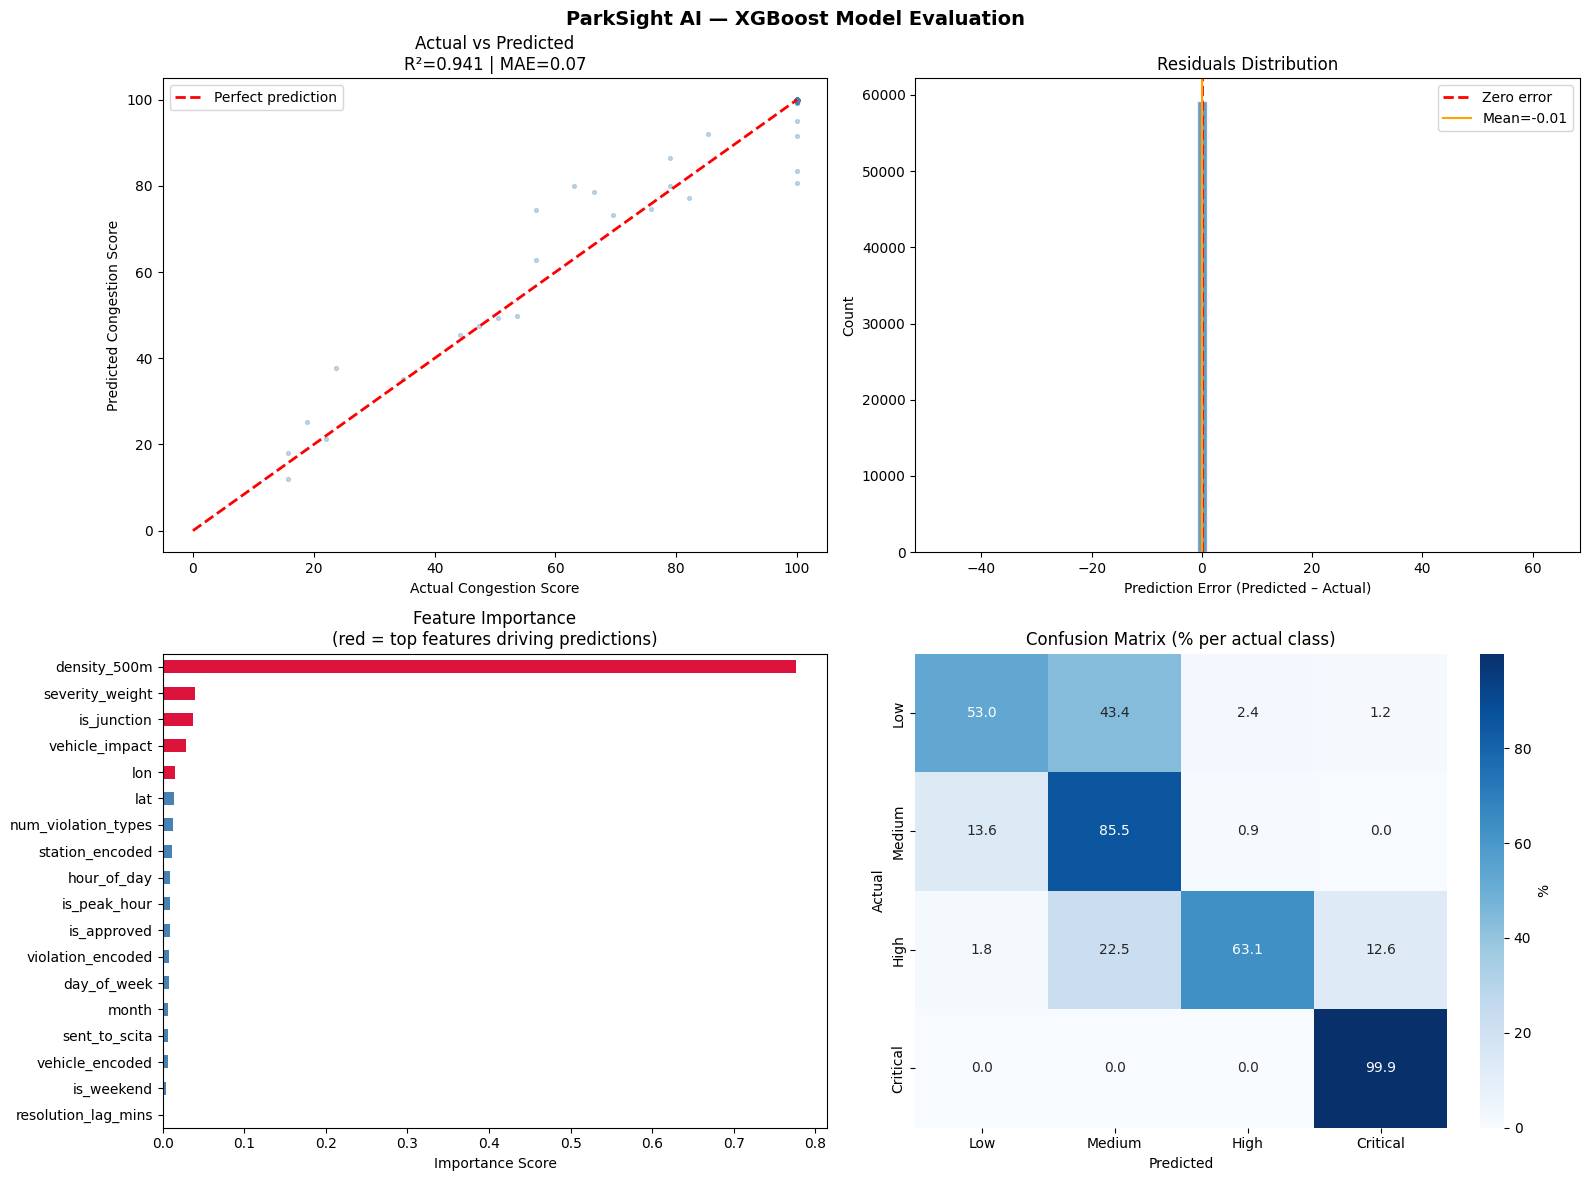

Saved: model_evaluation.png


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('ParkSight AI — XGBoost Model Evaluation', fontsize=14, fontweight='bold')

# ── 1. Actual vs Predicted scatter ───────────────────────────────────────────
idx = np.random.choice(len(y_test), min(3000, len(y_test)), replace=False)
axes[0,0].scatter(y_test[idx], y_pred[idx], alpha=0.3, s=8, color='steelblue')
axes[0,0].plot([0,100],[0,100], 'r--', lw=2, label='Perfect prediction')
axes[0,0].set_xlabel('Actual Congestion Score')
axes[0,0].set_ylabel('Predicted Congestion Score')
axes[0,0].set_title(f'Actual vs Predicted\nR²={r2:.3f} | MAE={mae:.2f}')
axes[0,0].legend()

# ── 2. Residuals histogram ───────────────────────────────────────────────────
residuals = y_pred - y_test
axes[0,1].hist(residuals, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[0,1].axvline(0, color='red', linestyle='--', lw=2, label='Zero error')
axes[0,1].axvline(residuals.mean(), color='orange', linestyle='-', lw=1.5, label=f'Mean={residuals.mean():.2f}')
axes[0,1].set_xlabel('Prediction Error (Predicted – Actual)')
axes[0,1].set_ylabel('Count')
axes[0,1].set_title('Residuals Distribution')
axes[0,1].legend()

# ── 3. Feature Importance ────────────────────────────────────────────────────
feat_imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
colors = ['crimson' if v > feat_imp.quantile(0.75) else 'steelblue' for v in feat_imp]
feat_imp.plot(kind='barh', ax=axes[1,0], color=colors)
axes[1,0].set_title('Feature Importance\n(red = top features driving predictions)')
axes[1,0].set_xlabel('Importance Score')

# ── 4. Confusion matrix ──────────────────────────────────────────────────────
label_order = ['Low', 'Medium', 'High', 'Critical']
cm = confusion_matrix(actual_labels, pred_labels, labels=label_order)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', ax=axes[1,1],
            xticklabels=label_order, yticklabels=label_order,
            cmap='Blues', cbar_kws={'label': '%'})
axes[1,1].set_title('Confusion Matrix (% per actual class)')
axes[1,1].set_ylabel('Actual')
axes[1,1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_evaluation.png')

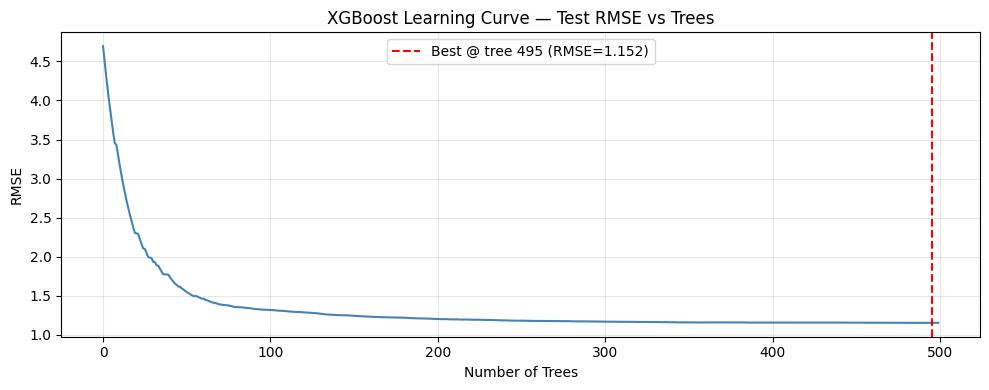

In [18]:
# ── Learning curve: how RMSE improves as more trees are added ────────────────
results = model.evals_result()
rmse_curve = results['validation_0']['rmse']

plt.figure(figsize=(10, 4))
plt.plot(rmse_curve, color='steelblue', lw=1.5)
best_iter = int(np.argmin(rmse_curve))
plt.axvline(best_iter, color='red', linestyle='--', label=f'Best @ tree {best_iter} (RMSE={rmse_curve[best_iter]:.3f})')
plt.xlabel('Number of Trees')
plt.ylabel('RMSE')
plt.title('XGBoost Learning Curve — Test RMSE vs Trees')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('learning_curve.png', dpi=150)
plt.show()

## Step 16: Save Model + Encoders → FastAPI will load these

In [19]:
import joblib

MODEL_DIR = 'backend/app/ml'
os.makedirs(MODEL_DIR, exist_ok=True)

# 1. XGBoost model (both formats)
model.save_model(f'{MODEL_DIR}/congestion_model.json')   # XGBoost native
joblib.dump(model,        f'{MODEL_DIR}/congestion_model.pkl')

# 2. Label encoders (needed to encode new records before prediction)
joblib.dump(le_violation, f'{MODEL_DIR}/le_violation.pkl')
joblib.dump(le_station,   f'{MODEL_DIR}/le_station.pkl')
joblib.dump(le_vehicle,   f'{MODEL_DIR}/le_vehicle.pkl')

# 3. Feature list (so backend knows the exact order)
joblib.dump(FEATURES,     f'{MODEL_DIR}/feature_names.pkl')

# 4. Model metadata
stats = {
    'mae': round(float(mae), 4),
    'rmse': round(float(rmse), 4),
    'r2': round(float(r2), 4),
    'train_samples': int(X_train.shape[0]),
    'test_samples': int(X_test.shape[0]),
    'n_features': len(FEATURES),
    'features': FEATURES,
    'severity_map': SEVERITY_MAP,
    'vehicle_impact_map': VEHICLE_IMPACT,
    'score_buckets': {'Low': [0,25], 'Medium': [25,50], 'High': [50,75], 'Critical': [75,100]},
    'violation_classes': le_violation.classes_.tolist(),
    'station_classes': le_station.classes_.tolist(),
    'vehicle_classes': le_vehicle.classes_.tolist(),
}

with open(f'{MODEL_DIR}/model_stats.json', 'w') as f:
    json.dump(stats, f, indent=2)

print('Files saved to backend/app/ml/:')
for fname in sorted(os.listdir(MODEL_DIR)):
    size_kb = os.path.getsize(f'{MODEL_DIR}/{fname}') / 1024
    print(f'  {fname:35s} {size_kb:8.1f} KB')

Files saved to backend/app/ml/:
  congestion_model.json                 2410.5 KB
  congestion_model.pkl                  1780.5 KB
  feature_names.pkl                        0.3 KB
  le_station.pkl                           1.2 KB
  le_vehicle.pkl                           0.7 KB
  le_violation.pkl                         0.9 KB
  model_stats.json                         3.4 KB


## Step 17: Live Prediction Test

This simulates exactly what the FastAPI endpoint will do when it receives a new violation from the frontend.

In [20]:
def predict_congestion(violation_dict):
    """
    Given a raw violation record (as the API would receive it),
    return congestion score, label and recommended action.
    """
    v = violation_dict
    
    # Encode categoricals (handle unseen values with try/except)
    try:
        v_enc = le_violation.transform([v['primary_violation'].upper().strip()])[0]
    except ValueError:
        v_enc = 0  # default: first class
    
    try:
        s_enc = le_station.transform([str(v['police_station']).strip()])[0]
    except ValueError:
        s_enc = 0
    
    try:
        vh_enc = le_vehicle.transform([str(v['vehicle_type']).upper().strip()])[0]
    except ValueError:
        vh_enc = 0
    
    feature_vector = np.array([[
        v['hour_of_day'],
        v['day_of_week'],
        v['month'],
        v['is_weekend'],
        v['is_peak_hour'],
        v['lat'],
        v['lon'],
        v['density_500m'],
        v['is_junction'],
        s_enc,
        v_enc,
        SEVERITY_MAP.get(v['primary_violation'].upper().strip(), DEFAULT_SEV),
        v.get('num_violation_types', 1),
        vh_enc,
        VEHICLE_IMPACT.get(v['vehicle_type'].upper().strip(), 1.0),
        v['resolution_lag_mins'],
        v.get('is_approved', 0),
        v.get('sent_to_scita', 0),
    ]])
    
    score = float(np.clip(model.predict(feature_vector)[0], 0, 100))
    label = score_to_label(score)
    action = ('Deploy 2 officers' if score > 80
              else 'CCTV challan' if score >= 60
              else 'Standard patrol')
    
    return {'score': round(score, 2), 'label': label, 'action': action}


# ── Test Cases ───────────────────────────────────────────────────────────────
test_violations = [
    {
        'name': 'WORST CASE: Double-parked truck at Koramangala junction, rush hour',
        'hour_of_day': 9, 'day_of_week': 1, 'month': 3,
        'is_weekend': 0, 'is_peak_hour': 1,
        'lat': 12.9255, 'lon': 77.6188,
        'density_500m': 20, 'is_junction': 1,
        'police_station': 'Madiwala',
        'primary_violation': 'DOUBLE PARKING',
        'num_violation_types': 2,
        'vehicle_type': 'TRUCK',
        'resolution_lag_mins': 150.0,
        'is_approved': 1, 'sent_to_scita': 1,
    },
    {
        'name': 'MODERATE: Wrong parking, main road, afternoon',
        'hour_of_day': 14, 'day_of_week': 2, 'month': 2,
        'is_weekend': 0, 'is_peak_hour': 0,
        'lat': 12.9054, 'lon': 77.7007,
        'density_500m': 8, 'is_junction': 0,
        'police_station': 'Bellandur',
        'primary_violation': 'PARKING IN A MAIN ROAD',
        'num_violation_types': 1,
        'vehicle_type': 'CAR',
        'resolution_lag_mins': 45.0,
        'is_approved': 1, 'sent_to_scita': 0,
    },
    {
        'name': 'LOW RISK: Scooter, no parking, Sunday quiet zone',
        'hour_of_day': 11, 'day_of_week': 6, 'month': 1,
        'is_weekend': 1, 'is_peak_hour': 0,
        'lat': 12.8900, 'lon': 77.5900,
        'density_500m': 2, 'is_junction': 0,
        'police_station': 'Madiwala',
        'primary_violation': 'NO PARKING',
        'num_violation_types': 1,
        'vehicle_type': 'SCOOTER',
        'resolution_lag_mins': 20.0,
        'is_approved': 0, 'sent_to_scita': 0,
    },
]

print('=== Live Prediction Test ===')
for v in test_violations:
    name = v.pop('name')
    result = predict_congestion(v)
    bar = '█' * int(result['score'] / 5)
    print(f'\n📍 {name}')
    print(f'   Score:  {result["score"]:5.1f}/100  {bar}')
    print(f'   Level:  {result["label"]}')
    print(f'   Action: {result["action"]}')

=== Live Prediction Test ===

📍 WORST CASE: Double-parked truck at Koramangala junction, rush hour
   Score:  100.0/100  ████████████████████
   Level:  Critical
   Action: Deploy 2 officers

📍 MODERATE: Wrong parking, main road, afternoon
   Score:   58.1/100  ███████████
   Level:  High
   Action: Standard patrol

📍 LOW RISK: Scooter, no parking, Sunday quiet zone
   Score:   33.6/100  ██████
   Level:  Medium
   Action: Standard patrol


## Step 18: Feature Importance → Dashboard Feature Mapping

In [ ]:
FEATURE_DASHBOARD_MAP = {
    'density_500m':         'HEATMAP — intensity of each map point',
    'resolution_lag_mins':  'ENFORCEMENT QUEUE — longer open = higher priority',
    'severity_weight':      'CONGESTION SCORE — violation type weight',
    'is_junction':          'CONGESTION SCORE — junction multiplier (3x vs 1.5x)',
    'vehicle_impact':       'CONGESTION SCORE — truck/bus blocks more road',
    'hour_of_day':          'TEMPORAL HEATMAP — 24-hour violation pattern',
    'is_peak_hour':         'TEMPORAL — rush hour risk flag',
    'day_of_week':          'TEMPORAL — Mon-Sun weekly pattern',
    'lat':                  'HEATMAP — geographic clustering (Bengaluru)',
    'lon':                  'HEATMAP — geographic clustering (Bengaluru)',
    'station_encoded':      'KPI DASHBOARD — which station has worst zones',
    'violation_encoded':    'ANOMALY — sudden shift in violation type patterns',
    'num_violation_types':  'CONGESTION SCORE — compound violations',
    'month':                'FORECAST — seasonal spikes (events, festivals)',
    'is_weekend':           'TEMPORAL — weekend vs weekday behaviour',
    'vehicle_encoded':      'OFFENDER PROFILING — vehicle category analysis',
    'is_approved':          'KPI — enforcement quality / challan acceptance rate',
    'sent_to_scita':        'SCITA TAB — escalation to traffic control room',
}

importance_df = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': model.feature_importances_,
    'Dashboard Feature': [FEATURE_DASHBOARD_MAP.get(f, '') for f in FEATURES]
}).sort_values('Importance', ascending=False)

print('\n=== TOP FEATURES driving the model (sorted by importance) ===\n')
for _, row in importance_df.iterrows():
    bar = '█' * int(row['Importance'] * 200)
    print(f"{row['Feature']:25s} {row['Importance']:.4f} {bar}")
    print(f"  → {row['Dashboard Feature']}")

importance_df.to_csv('feature_importance.csv', index=False)
print('\nSaved: feature_importance.csv')

---
## Summary

| What was produced | File |
|---|---|
| Trained XGBoost model | `backend/app/ml/congestion_model.pkl` |
| Violation type encoder | `backend/app/ml/le_violation.pkl` |
| Police station encoder | `backend/app/ml/le_station.pkl` |
| Vehicle type encoder | `backend/app/ml/le_vehicle.pkl` |
| Model stats (MAE/RMSE/R²) | `backend/app/ml/model_stats.json` |
| Evaluation charts | `model_evaluation.png`, `learning_curve.png` |

### Next Step
Load `congestion_model.pkl` in FastAPI → replace rule-based `scoring.py` → all dashboard features use real predictions.

```python
# In FastAPI startup:
import joblib
model = joblib.load('backend/app/ml/congestion_model.pkl')
```